In [1]:
%%bash
git clone https://github.com/ahaberlie/SVRIMG.git > /dev/null
cd SVRIMG && pip install . > /dev/null
pip install cartopy > /dev/null
pip install scikit-learn > /dev/null

Cloning into 'SVRIMG'...


# Chapter 9.4 - Image Feature Extraction

[Image Feature extraction and detection](https://en.wikipedia.org/wiki/Feature_(computer_vision)) is the general approach to identifying patterns in a digital image.

We should define some terms (some new and some reminders) before we go further:

**Big Terms**

- `Feature detection`: deciding whether a specific structure is present, and often where it is.

- `Feature extraction`: computing informative descriptors, measurements, or representations from the image.

- `Traditional feature detection / extraction`: Engineered or hand-crafted mathematical operations that are designed for a specific feature.

- `"Deep learning" feature detection / extraction`: data-derived mathematical operations that are designed to optimize some machine learning task (image classification, segmentation, object detection, etc.)

- `Scale`: The spatial size at which a structure is analyzed. In the geosciences, this is determined by metadata and best practices. For example, using a 10x10 pixel neighborhood to identify a frontal boundary or fault line (often 1000 km long and 10 km wide) is not useful if each pixel represents a 30 cm area.

- `Region` or `patch`: a small subset of an image that is grouped based on the output from a local operation.

- `Feature`: a measurable property of an image that can be used in machine learning classification tasks.

- `Feature map`: the combined responses produced by operations applied to an image. This can be the exact size of the original image or smaller.

- `Descriptor`: a numeric summary of a region, object, image, etc.

- `Response`: a numeric result of an operation.





**Total image statistics**

- `Global operation`: an operation in which the output is based on the entire image or a large part of the image.

- `Non-linear filter`: an operation applied to an image that fails to satisfy at least one of the two properties required for linearity: additivity or homogeneity. For example, thresholding an image results in either a 0 (False) or 1 (True). If you apply a threshold of 100 to a pixel with a value of 60, you get 0. If you multiply that pixel by 10 and apply the threshold of 100 test again, you get 1, even though the pixel value increased 10x. Therefore, the output does not scale proportionally with the input, so homogeneity is not satisfied.

We can run descriptive statistics on the entire image. `min` is an example of a non-linear filter. A 2x increase in `example` results in no change in `min`.

mean  : 4.92
median: 5.5
min   : 0
max   : 9
(2x) mean  : 9.84
(2x) median: 11.0
(2x) min   : 0
(2x) max   : 18


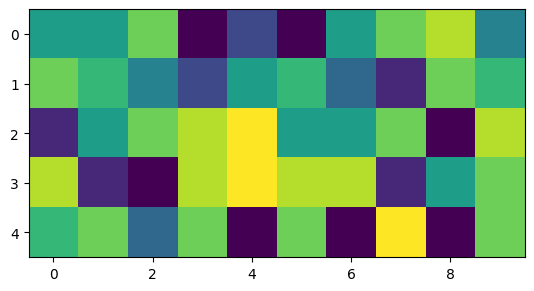

In [2]:
import matplotlib.pyplot as plt
import numpy as np

example = np.random.randint(low=0, high=10, size=(5,10))
plt.imshow(example)

print("mean  :", example.mean())
print("median:", np.median(example))
print("min   :", example.min())
print("max   :", example.max())

print("(2x) mean  :", (2*example).mean())
print("(2x) median:", np.median((2*example)))
print("(2x) min   :", (2*example).min())
print("(2x) max   :", (2*example).max())

**Basic image properties**

- `Pixel`: the smallest element of a digital image that stores intensity or other information associated with the region that pixel represents.

- `Image`: a structure containing two or more pixels and their locations.

- `Spatial location`: the row/column position of a pixel or other grouping of interest within an image.

The following example shows an `image` with random `pixel` values. Using `np.where`, we can extract the location of pixels that meet some condtion.

In [3]:
pts = np.where(example == 9)
yx = [(int(x), int(y)) for x, y in zip(pts[0], pts[1])]

print("Positions where pixel value is 9 (y, x)", yx)

Positions where pixel value is 9 (y, x) [(2, 4), (3, 4), (4, 7)]


**Image subsets and subset filters**

- `Local neighborhood`: a small, spatially contiguous subset of an image.

- `Local neighborhood operation`: an operation in which the output at each spatial location is computed from a small neighborhood of pixels around that location.

- `Linear filter`: An operation satisfying linearity (e.g., convolution with a kernel). This type of filter requires additivity (i.e., an image is just a sum of linear features) and homogeneity (i.e., the output scales in direct proportion to the input intensity values). For example, if you have three neighboring pixels of 0, 1, and 2 dBZ in the x-dimension and apply a gradient operation, you will get a local gradient of 1 dBZ pixel$^{-1}$. If you multiply the values by 5, resulting in pixel values of 0, 5, and 10, the new local gradient is 5 dBZ pixel$^{-1}$.

We can use index slicing to identify regions in an image and then apply some operation to each pixel. For example, we run `np.mean` which is equivalent to blur operation (a linear filter).

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from ipywidgets import interact

nrows, ncols = example.shape[:2]

def show_neighborhood(ys=0, ye=3, xs=0, xe=2, mult=1):
    if ys >= ye or xs >= xe:
        print("Require ys < ye and xs < xe")
        return

    eg = example.copy()

    eg *= mult

    neighborhood = eg[ys:ye, xs:xe]

    plt.figure(figsize=(8, 4))

    ax = plt.subplot(1, 2, 1)
    ax.set_title("Original Image")
    ax.imshow(eg, vmin=0, vmax=np.max(eg))

    rect = Rectangle(
        (xs - 0.5, ys - 0.5),
        xe - xs,
        ye - ys,
        fill=False,
        edgecolor="red",
        linewidth=2
    )
    ax.add_patch(rect)

    ax = plt.subplot(1, 2, 2)
    ax.imshow(neighborhood, vmin=0, vmax=np.max(eg))
    ax.set_title(f"Local Neighborhood\nrows {ys}:{ye}, cols {xs}:{xe}\nmean = {np.mean(neighborhood):.2f}")

    plt.tight_layout()
    plt.show()

interact(
    show_neighborhood,
    ys=widgets.IntSlider(min=0, max=nrows-1, step=1, value=0, description="ys"),
    ye=widgets.IntSlider(min=1, max=nrows,   step=1, value=min(3, nrows), description="ye"),
    xs=widgets.IntSlider(min=0, max=ncols-1, step=1, value=0, description="xs"),
    xe=widgets.IntSlider(min=1, max=ncols,   step=1, value=min(2, ncols), description="xe"),
    mult=widgets.IntSlider(min=1, max=10,   step=1, value=1, description="mult"),
);

interactive(children=(IntSlider(value=0, description='ys', max=4), IntSlider(value=3, description='ye', max=5,…

**Local neighborhood operations**

- `Window` / `kernel` / `filter mask`: a small array that is used to perform a local neighborhood operation.

- `Convolution`: a local weighted-sum operation using a kernel.

- `Correlation`: a local weighted-sum operation similar to convolution, except the kernel is applied "as-is" and not flipped 180 degrees. In many contexts, especially deep learning, this is colloquially called "convolution" even though it is mathematically correlation. Symmetric kernels give the same absolute response in convolution or correlation.

- `Edge`: a region with marked changes in intensity.

We can define a kernel (e.g., an edge detection kernel) and run a convolution or a correlation. We can import pre-defined filter methods from `skimage`. For edges, we will use [`skimage.filters.sobel`](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.sobel). This method takes an image and finds edges in vertical and horizontal dimensions and returns absolute values from convolution. If you increase (decrease) the values in the "cross", the edge extraction will produce higher (lower) values.

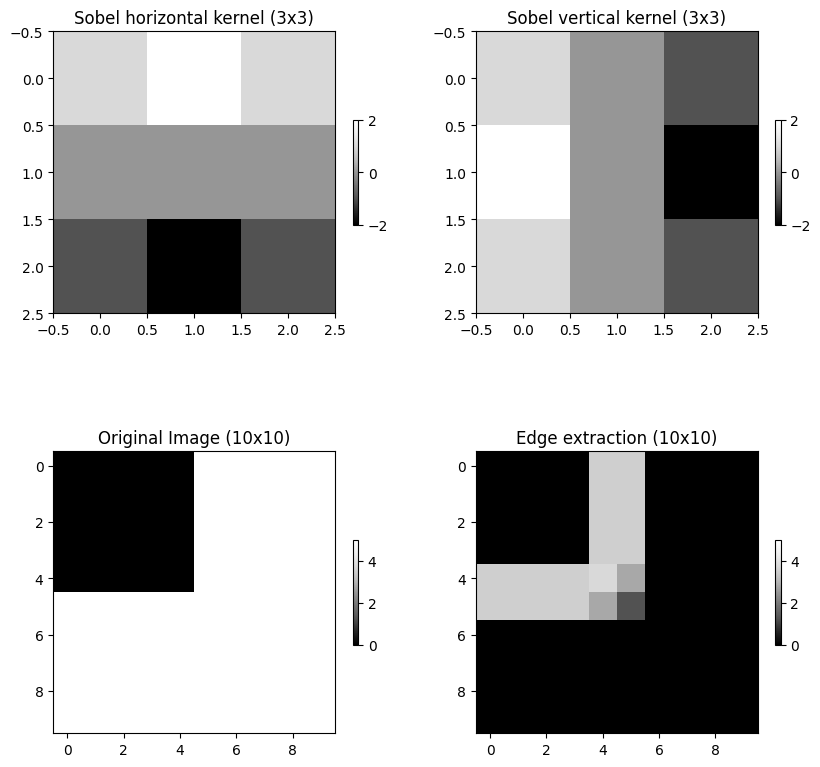

In [5]:
from skimage.filters import sobel
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = 10, 10

img = np.zeros((10, 10), dtype=float)
img[:, 5:] = 5.0
img[5:, :] = 5.0

sobel_h = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
])

sobel_v = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1]
])

ax = plt.subplot(2, 2, 1)
ax.set_title("Sobel horizontal kernel (3x3)")
mmp = ax.imshow(sobel_h, cmap='Greys_r')
plt.colorbar(mmp, ax=ax, shrink=0.3)

ax = plt.subplot(2, 2, 2)
ax.set_title("Sobel vertical kernel (3x3)")
mmp = ax.imshow(sobel_v, cmap='Greys_r')
plt.colorbar(mmp, ax=ax, shrink=0.3)

ax = plt.subplot(2, 2, 3)
mmp = ax.imshow(img, vmin=0, vmax=5, cmap='Greys_r')
ax.set_title("Original Image (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

edges = sobel(img)

ax = plt.subplot(2, 2, 4)
mmp = ax.imshow(edges, vmin=0, vmax=5, cmap='Greys_r')
ax.set_title("Edge extraction (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)









- `Corner`: a region with marked changes in intensity in more than one direction.

We can detect corners using `skimage.feature.corner_harris`. Notice that the highest values are clustered around the bend in the `L`.

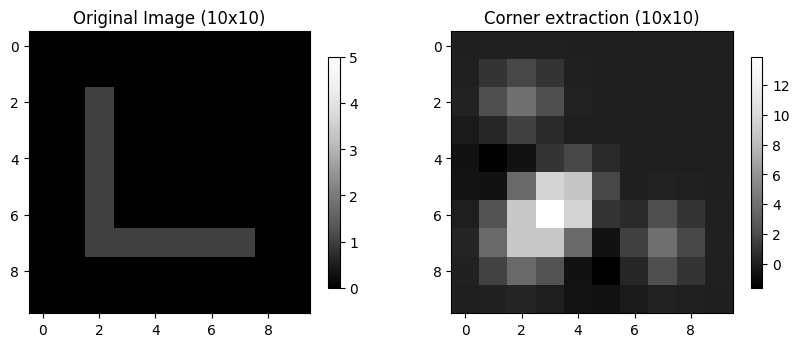

In [6]:
from skimage.feature import corner_harris

corner_img = np.zeros((10, 10), dtype=float)
corner_img[2:8, 2:3] = 1.0
corner_img[7:8, 2:8] = 1.0

corner_response = corner_harris(corner_img)

ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(corner_img, vmin=0, vmax=5, cmap='Greys_r')
ax.set_title("Original Image (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(corner_response, cmap='Greys_r')
ax.set_title("Corner extraction (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)



- `Blob`: a contiguous group of pixels distinct from surrounding pixels.

We can use [`skimage.feature.blob_log`](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.blob_log). This approach uses the [`Laplacian of Gaussian (LoG)`](https://en.wikipedia.org/wiki/Blob_detection#The_Laplacian_of_Gaussian) method with some arguments:

- `min_sigma`: the smallest blob sizes to detect.
- `max_sigma`: the largest blob sizes to detect.
- `num_sigma`: how many size thresholds to test between min and max sigma.
- `threshold`: the sensitivity of the method. Lower values are more sensitive.


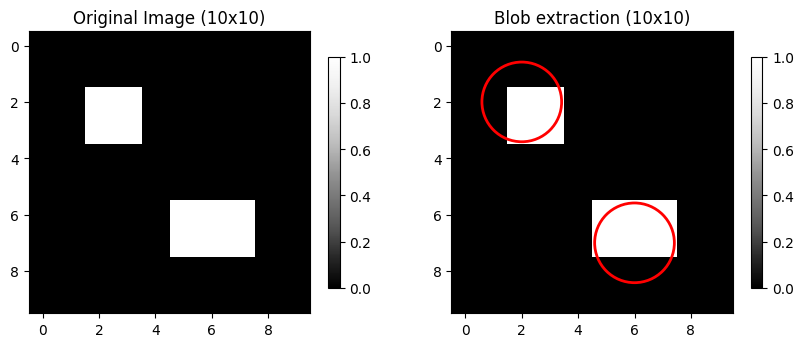

In [7]:
from skimage.feature import blob_log

blob_img = np.zeros((10, 10), dtype=float)
blob_img[2:4, 2:4] = 1.0
blob_img[6:8, 5:8] = 1.0

ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(blob_img, cmap='Greys_r')
ax.set_title("Original Image (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(blob_img, cmap='Greys_r')
ax.set_title("Blob extraction (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

blob_response = blob_log(blob_img, min_sigma=1.0, max_sigma=2.5, num_sigma=10, threshold=0.05)

blob_response[:, 2] = blob_response[:, 2] * np.sqrt(2)
for y, x, r in blob_response:
    ax.add_patch(plt.Circle((x, y), r, color='red', fill=False, linewidth=2))


- `Ridge`: a local maximum (minimum) in pixel intensity surrounded by lower (higher) values.

We can use `skimage.filters.hessian` to identify thin local max/min pixels.

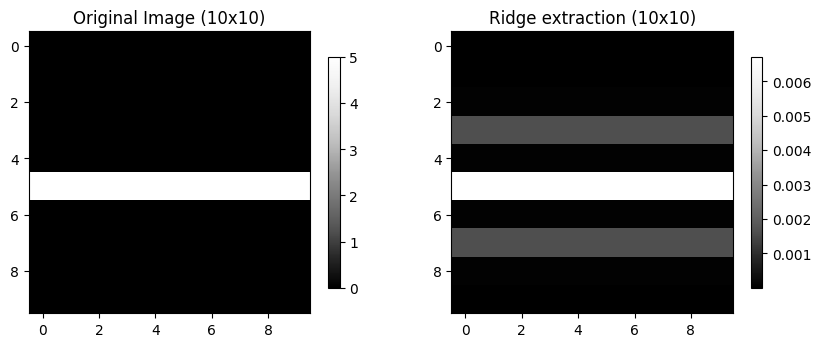

In [8]:
from skimage.filters import hessian

ridge_img = np.zeros((10, 10), dtype=float)
ridge_img[5:6, :] = 5.0

ridge_response = hessian(ridge_img)

ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(ridge_img, cmap='Greys_r')
ax.set_title("Original Image (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(ridge_response, cmap='Greys_r')
ax.set_title("Ridge extraction (10x10)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

### Chapter 9.4.1 - SVRIMG

[SVRIMG (SeVeRe IMaGes)](https://nimbus.niu.edu/svrimg/) is an educational machine learning dataset made for demonstrating image classification tasks. It is inspired by the [MNIST](https://en.wikipedia.org/wiki/MNIST_database) written number classification dataset.


<img src=https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png></img>

Instead of written numbers, the images are [composite radar reflectivity images](https://gridrad.org/) centered on [tornado reports](https://www.spc.noaa.gov/wcm/#data) supplied by the [Storm Prediction Center](https://www.spc.noaa.gov/).

The radar images include the following storm mode (e.g., [cellular](https://en.wikipedia.org/wiki/Supercell), [mesoscale convective systems](https://en.wikipedia.org/wiki/Mesoscale_convective_system)) structures:


- `Cellular`: circular areas of greater than 50 dBZ that have notable spacing between them

> ![Cellular](https://nimbus.niu.edu/svrimg/data/2011/201105242020z000315803.png)

- `QLCS`: linear areas of greater than 50 dBZ that are longer than 100 km in length

> ![QLCS](https://nimbus.niu.edu/svrimg/data/2011/201104200257z000309225.png)

- `Tropical`: areas of moderate (~30-40 dBZ) precipitation intensity that have a circular and spiraling character.

> ![Tropical](https://nimbus.niu.edu/svrimg/data/2005/200510241000z000000492.png)

- `Other`: morphologies that do not fit in to one of the previous classes.

> ![Other](https://nimbus.niu.edu/svrimg/data/2005/200507252053z000000288.png)

- `Noise`: low intensity rings, spikes, or pixelation that do not look natural.

> ![Noise](https://nimbus.niu.edu/svrimg/data/1996/199610211610z000000787.png)

- `Missing`: no dBZ or images on the edge of the domain.

> ![Missing](https://nimbus.niu.edu/svrimg/data/2007/200706011655z000000663.png)

The SVRIMG package was installed in this notebook. We can download sample data using the `get_example_data` utility:

In [9]:
from svrimg.utils.get_images import get_example_data

(x_train, y_train) = get_example_data('training', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_val, y_val) = get_example_data('validation', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_test, y_test) = get_example_data('testing', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")

We can examine the data and see that they are just groups of images and labels. Specifically, they have been organized into training, validation, and testing data. The brighter colors mean higher dBZ, and darker colors mean lower dBZ in the image below:

x_train shape: (1331, 136, 136, 1)
x_val shape: (110, 136, 136, 1)
x_test shape: (300, 136, 136, 1)


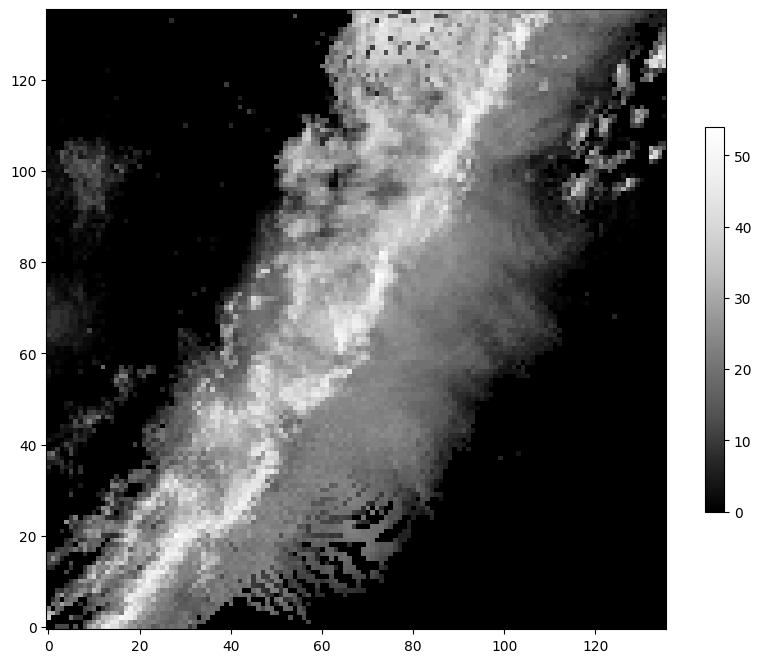

In [10]:
print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

plt.imshow(x_train[56, :, :].squeeze(), cmap='Greys_r', origin='lower')
plt.colorbar(shrink=0.5)

The `y` data are the labels. We can examine those values and see that there are a matching number of labels in each subset. In addition, the unique values are integers from 0 to 5. Each integer represents one of the storm modes described above.

In [11]:
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

label_names = ['Cellular', 'QLCS', 'Tropical', 'Other', 'Noise', 'Missing']

for value, name in enumerate(label_names):
    print(f"Label value {value} represents mode {name}")



y_train shape: (1331,)
y_val shape: (110,)
y_test shape: (300,)
Label value 0 represents mode Cellular
Label value 1 represents mode QLCS
Label value 2 represents mode Tropical
Label value 3 represents mode Other
Label value 4 represents mode Noise
Label value 5 represents mode Missing


### Chapter 9.4.2 - Training traditional models: Random forest

Recall that Random forest (RF) requires training data to be in a tabular format (i.e., one-dimensional data). So, we need to find a way to convert the 2-D image data to a tabular format.

The easiest way is to flatten the image. The new shape would be (number_of_samples, 136 * 136), where 136 x 136 is the image size.

In [12]:
x_rf_train = x_train.reshape(x_train.shape[0], 136*136)
x_rf_val = x_val.reshape(x_val.shape[0], 136*136)
x_rf_test = x_test.reshape(x_test.shape[0], 136*136)

print("New train shape = ", x_rf_train.shape)
print("New val shape = ", x_rf_val.shape)
print("New test shape = ", x_rf_test.shape)

New train shape =  (1331, 18496)
New val shape =  (110, 18496)
New test shape =  (300, 18496)


Now, you can train and test the RF classifier:

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(x_rf_train, y_train)

RandomForestClassifier(random_state=42)

Now we can look at the results using the testing dataset. The results are not not terrible, but not as good as they could be.

              precision    recall  f1-score   support

           0       0.68      0.91      0.78        78
           1       0.91      0.89      0.90       152
           2       0.70      0.79      0.74        33
           3       0.00      0.00      0.00        11
           4       0.00      0.00      0.00         2
           5       1.00      0.42      0.59        24

    accuracy                           0.81       300
   macro avg       0.55      0.50      0.50       300
weighted avg       0.80      0.81      0.79       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


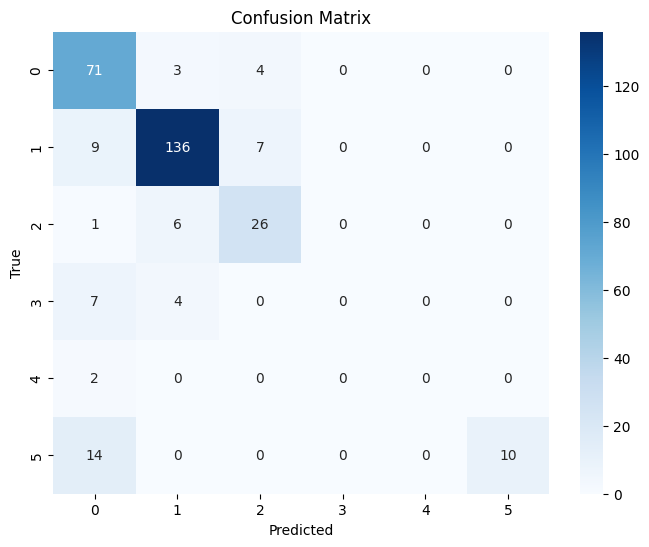

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict the labels for the test set
y_pred = rf_classifier.predict(x_rf_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

# Print the classification report
print(classification_report(y_test, y_pred))

Additionally, it is difficult to interpret the variable importance. For example, what is feature 9977? why is it more important than feature 10113?

In [15]:
import pandas as pd

importances = rf_classifier.feature_importances_
feature_importances = pd.DataFrame({'Feature': range(x_rf_train.shape[1]), 'Importance': importances})
feature_importances = feature_importances.sort_values('Importance', ascending=False)
display(feature_importances)

,Feature,Importance
9977,9977,0.004457
10113,10113,0.004373
12437,12437,0.004247
9570,9570,0.004078
10383,10383,0.004019
...,...,...
5241,5241,0.000000
5240,5240,0.000000
5239,5239,0.000000
5238,5238,0.000000


**We will continue this exploration in Lab 11**